# Credit Risk Prediction

## Intoduction and Problem Statement`

#### In this task we have to load a loan prediction dataset using kaggle . In the dataset there might be some missing data we have to handle them . Moreover we need to visuallize the fetures of dataset. Then train a classification model and evaluate the model.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("loan_data[1].csv")  
df

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,LP216038,Female,No,2,Graduate,No,4809.0,3329.0,3650.0,180,Rural,Yes
1,LP288956,Female,Yes,1,Graduate,No,3358.0,NaN,6680.0,360,Rural,No
2,LP153364,Female,Yes,1,Graduate,No,9873.0,1649.0,NaN,360,Semiurban,No
3,LP945891,Male,No,0,Graduate,Yes,11665.0,4378.0,8366.0,360,Rural,Yes
4,LP425056,Female,No,1,Graduate,No,5890.0,1523.0,8741.0,180,Urban,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,LP693571,Male,Yes,3+,Graduate,Yes,8998.0,2137.0,2487.0,360,Semiurban,Yes
9996,LP193182,Female,No,1,Graduate,Yes,7186.0,NaN,5380.0,360,Rural,Yes
9997,LP668937,Male,No,0,Not Graduate,No,2778.0,678.0,2794.0,180,Rural,Yes
9998,LP447580,Male,No,3+,Graduate,Yes,4746.0,1172.0,NaN,180,Semiurban,No


In [4]:
df.head()

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,LP216038,Female,No,2,Graduate,No,4809.0,3329.0,3650.0,180,Rural,Yes
1,LP288956,Female,Yes,1,Graduate,No,3358.0,NaN,6680.0,360,Rural,No
2,LP153364,Female,Yes,1,Graduate,No,9873.0,1649.0,NaN,360,Semiurban,No
3,LP945891,Male,No,0,Graduate,Yes,11665.0,4378.0,8366.0,360,Rural,Yes
4,LP425056,Female,No,1,Graduate,No,5890.0,1523.0,8741.0,180,Urban,Yes


In [5]:
df.tail()

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
9995,LP693571,Male,Yes,3+,Graduate,Yes,8998.0,2137.0,2487.0,360,Semiurban,Yes
9996,LP193182,Female,No,1,Graduate,Yes,7186.0,NaN,5380.0,360,Rural,Yes
9997,LP668937,Male,No,0,Not Graduate,No,2778.0,678.0,2794.0,180,Rural,Yes
9998,LP447580,Male,No,3+,Graduate,Yes,4746.0,1172.0,NaN,180,Semiurban,No
9999,LP146890,Female,Yes,1,Graduate,No,NaN,1839.0,6084.0,360,Rural,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           10000 non-null  object 
 1   Gender                10000 non-null  object 
 2   Marital_Status        10000 non-null  object 
 3   Number_of_Dependents  10000 non-null  object 
 4   Education             10000 non-null  object 
 5   Loan_Status           10000 non-null  object 
 6   Annual_Income         9000 non-null   float64
 7   Credit_Score          8979 non-null   float64
 8   Loan_Amount           8987 non-null   float64
 9   Term                  10000 non-null  int64  
 10  Property_Area         10000 non-null  object 
 11  Loan_Approval         10000 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 937.6+ KB


In [7]:
df.describe()

,Annual_Income,Credit_Score,Loan_Amount,Term
count,9000.000000,8979.000000,8987.000000,10000.000000
mean,6740.199667,2622.278316,4995.397797,269.334000
std,3019.882729,1381.345574,2860.382446,90.002036
min,1500.000000,0.000000,0.000000,180.000000
25%,4181.000000,1437.000000,2529.500000,180.000000
50%,6669.000000,2627.000000,5021.000000,180.000000
75%,9333.000000,3800.000000,7460.500000,360.000000
max,12000.000000,5000.000000,10000.000000,360.000000


In [8]:
df.shape

(10000, 12)

In [9]:
df.columns

Index(['Customer_ID', 'Gender', 'Marital_Status', 'Number_of_Dependents',
       'Education', 'Loan_Status', 'Annual_Income', 'Credit_Score',
       'Loan_Amount', 'Term', 'Property_Area', 'Loan_Approval'],
      dtype='object')

In [10]:
## Check missing values
df.isnull().sum()

Customer_ID                0
Gender                     0
Marital_Status             0
Number_of_Dependents       0
Education                  0
Loan_Status                0
Annual_Income           1000
Credit_Score            1021
Loan_Amount             1013
Term                       0
Property_Area              0
Loan_Approval              0
dtype: int64

In [11]:
# Fill numerical columns with median values

df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())

df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())

df['Loan_Amount'] = df['Loan_Amount'].fillna(df['Loan_Amount'].median())

In [12]:
df.isnull().sum()

Customer_ID             0
Gender                  0
Marital_Status          0
Number_of_Dependents    0
Education               0
Loan_Status             0
Annual_Income           0
Credit_Score            0
Loan_Amount             0
Term                    0
Property_Area           0
Loan_Approval           0
dtype: int64

## Exploratory Data Analysis (EDA)

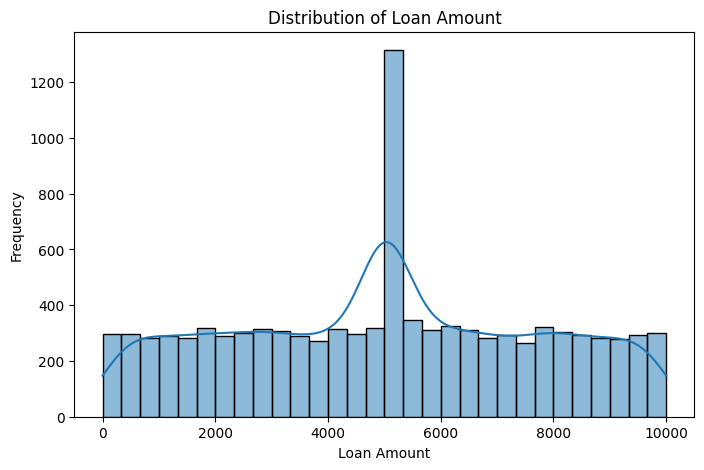

In [14]:
# Aalyzing how the loan amounts are distributed among applicants 
plt.figure(figsize=(8,5))
sns.histplot(df['Loan_Amount'], bins=30, kde=True)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

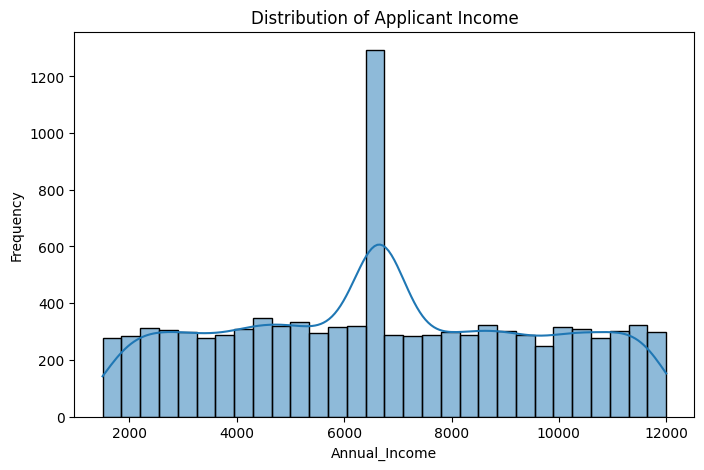

In [18]:
#Income visualiztaion 
plt.figure(figsize=(8,5))
sns.histplot(df['Annual_Income'], bins=30, kde=True)

plt.title('Distribution of Applicant Income')
plt.xlabel('Annual_Income')
plt.ylabel('Frequency')

plt.show()

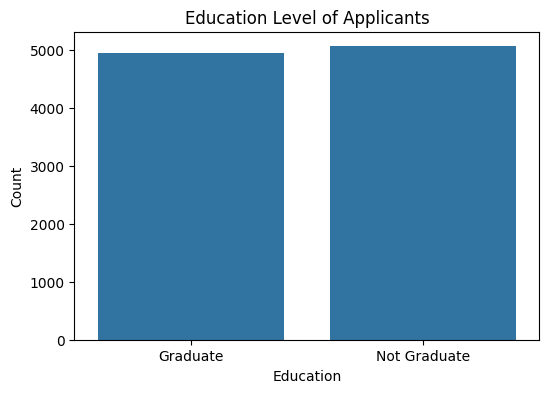

In [15]:
# This shows the number of  graduates 
plt.figure(figsize=(6,4))
sns.countplot(x='Education', data=df)

plt.title('Education Level of Applicants')
plt.xlabel('Education')
plt.ylabel('Count')

plt.show()


# Encoding

In [19]:
# Converting categorical data into numbers 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,1211,0,0,2,0,0,4809.0,3329.0,3650.0,180,0,1
1,2022,0,1,1,0,0,3358.0,2627.0,6680.0,360,0,0
2,545,0,1,1,0,0,9873.0,1649.0,5021.0,360,1,0
3,9301,1,0,0,0,1,11665.0,4378.0,8366.0,360,0,1
4,3541,0,0,1,0,0,5890.0,1523.0,8741.0,180,2,1


In [21]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [22]:
# Splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [23]:
# Training Logistic regression 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10000)

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.5255


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[517 489]
 [460 534]]


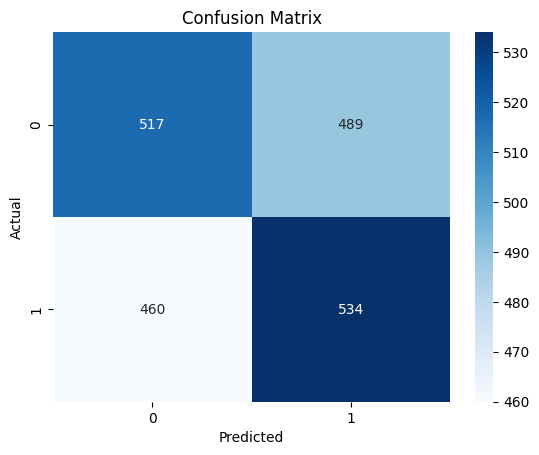

In [28]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Conclusion

#### In this I have used the Loan Prediction Dataset to analyze and predict loan approval outcomes. We handled missing values, performed data visualization on key features like income, loan amount, and education, and prepared the data for modeling. A Logistic Regression model was trained and evaluated using accuracy and a confusion matrix. This project helped us understand the complete machine learning workflow from data preprocessing to model evaluation.